In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import muon as mu
import scanpy as sc
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests
import sys
np.random.seed(42)

sys.path.append(r"/ihome/ylee/yiz133/Code/Data processing/functions/")
import TCR_embedings

2026-05-22 13:50:01.590780: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-22 13:50:01.629564: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-22 13:50:02.805293: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-22 13:50:07.002485: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or

## 1. Load data

In [2]:
# ── paths ──────────────────────────────────────────────────────────────────
path = r"/ix1/ylee/Yifan_Zhang/Code_data/Tumor/GSE139555_2019/data/Processed/"
T_filename  = "T_DE_per_sample_TCRemb.h5mu"
PSEUDO_filename   = "CD8_DE2500_singleVDJ_emb_pseudo.h5ad"

mdata_ori = mu.read(path + T_filename)
adata_ps  = sc.read_h5ad(path + PSEUDO_filename)


print("COMBAT mdata:", mdata_ori)
print("\nPseudotime adata:", adata_ps)

COMBAT mdata: MuData object with n_obs × n_vars = 51775 × 2551
  obs:	'isT', 'ident', 'patient', 'source', 'type', 'subtype', 'clone_loc', 'unique_clone_id', 'cloned', 'in_two_tissue', 'clone_status', 'VJ_1_cdr3_aa', 'VJ_1_v_call', 'VJ_1_j_call', 'VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call', 'VDJ_1_cdr3_aa_length', 'VJ_1_cdr3_aa_length'
  uns:	'hvg_union_COMBAT_ID_meta', 'tcr_embs_feature_names'
  obsm:	'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_j_call', 'VJ_1_v_call', 'X_VDJ_1_cdr3_aa_atchley', 'X_VDJ_1_cdr3_aa_composition', 'X_VJ_1_cdr3_aa_atchley', 'X_VJ_1_cdr3_aa_composition', 'tcr_embs'
  2 modalities
    gex:	51775 x 2551
      obs:	'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_c

In [3]:
# Detect all pseudotime columns
pseudo_cols = [c for c in adata_ps.obs.columns if 'pseudotime' in c.lower()]
print("Pseudotime columns found:", pseudo_cols)
adata_ps.obs[pseudo_cols].describe()

Pseudotime columns found: ['palantir_pseudotime']


,palantir_pseudotime
count,14957.000000
mean,0.540194
std,0.135893
min,0.000000
25%,0.480858
50%,0.548998
75%,0.615525
max,1.000000


## 2. Intersect cells

In [4]:
combat_idx = pd.Index(mdata_ori.obs_names)
pseudo_idx = pd.Index(adata_ps.obs_names)
shared_idx = combat_idx.intersection(pseudo_idx)

print(f"COMBAT cells    : {len(combat_idx):,}")
print(f"Pseudotime cells: {len(pseudo_idx):,}")
print(f"Shared cells    : {len(shared_idx):,}")

mdata = mdata_ori[shared_idx].copy()
adata = adata_ps[shared_idx].copy()

for col in pseudo_cols:
    mdata['gex'].obs[col] = adata.obs[col].values

print("\nSubset mdata:", mdata)

COMBAT cells    : 51,775
Pseudotime cells: 14,957
Shared cells    : 14,957

Subset mdata: MuData object with n_obs × n_vars = 14957 × 2551
  obs:	'isT', 'ident', 'patient', 'source', 'type', 'subtype', 'clone_loc', 'unique_clone_id', 'cloned', 'in_two_tissue', 'clone_status', 'VJ_1_cdr3_aa', 'VJ_1_v_call', 'VJ_1_j_call', 'VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call', 'VDJ_1_cdr3_aa_length', 'VJ_1_cdr3_aa_length'
  uns:	'hvg_union_COMBAT_ID_meta', 'tcr_embs_feature_names'
  obsm:	'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_j_call', 'VJ_1_v_call', 'X_VDJ_1_cdr3_aa_atchley', 'X_VDJ_1_cdr3_aa_composition', 'X_VJ_1_cdr3_aa_atchley', 'X_VJ_1_cdr3_aa_composition', 'tcr_embs'
  2 modalities
    gex:	14957 x 2551
      obs:	'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt',

## 3. Aggregate to clone level

In [5]:
clone_id_series = mdata.obs['unique_clone_id'].astype(str)

tcr_embs       = np.asarray(mdata.obsm['tcr_embs'], dtype=float)
tcr_feat_names = list(mdata.uns.get('tcr_embs_feature_names',
                                     [f'tcr_{i}' for i in range(tcr_embs.shape[1])]))

df_tcr = pd.DataFrame(tcr_embs, index=mdata.obs_names, columns=tcr_feat_names)
df_tcr['clone_id'] = clone_id_series.values

df_ps  = adata.obs[pseudo_cols].copy()
df_ps['clone_id'] = clone_id_series.values

# Mean per clone (TCR identical within a clone; pseudotime averaged)
clone_tcr = df_tcr.groupby('clone_id')[tcr_feat_names].mean()
clone_ps  = df_ps.groupby('clone_id')[pseudo_cols].mean()

common_clones = clone_tcr.index.intersection(clone_ps.index)
clone_tcr = clone_tcr.loc[common_clones]
clone_ps  = clone_ps.loc[common_clones]

# Drop clones with any NaN pseudotime
valid = clone_ps.notna().all(axis=1)
clone_tcr = clone_tcr[valid]
clone_ps  = clone_ps[valid]

print(f"Clones after aggregation : {len(clone_tcr):,}")
print(f"TCR features             : {clone_tcr.shape[1]}")
print(f"Pseudotime cols          : {clone_ps.shape[1]}  →  {pseudo_cols}")
clone_ps.describe()

Clones after aggregation : 4,927
TCR features             : 405
Pseudotime cols          : 1  →  ['palantir_pseudotime']


,palantir_pseudotime
count,4927.000000
mean,0.570959
std,0.122204
min,0.014432
25%,0.503049
50%,0.566411
75%,0.636360
max,1.000000


## 4. PCA on clone-level TCR embeddings

PCA: 5 components, cumulative variance explained:
  top  5 PCs: 8.3%
  top  5 PCs: 8.3%
  top  5 PCs: 8.3%
  top  5 PCs: 8.3%


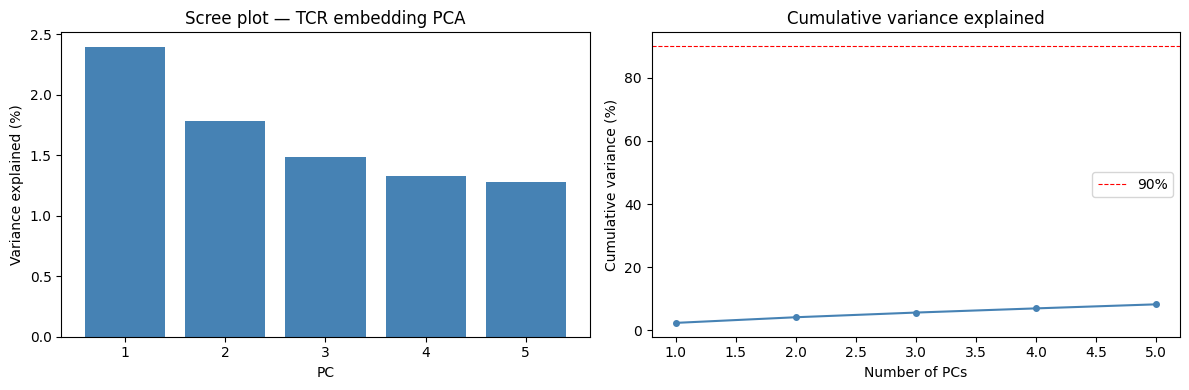

In [6]:
# n_pca = min(50, clone_tcr.shape[1], clone_tcr.shape[0] - 1)
n_pca = 5

scaler_tcr = StandardScaler()
tcr_scaled = scaler_tcr.fit_transform(clone_tcr.values)

pca = PCA(n_components=n_pca, random_state=42)
tcr_pcs = pca.fit_transform(tcr_scaled)          # (n_clones, n_pca)
pc_names = [f'PC_{i+1}' for i in range(n_pca)]

var_exp = pca.explained_variance_ratio_
print(f"PCA: {n_pca} components, cumulative variance explained:")
for k in [5, 10, 20, n_pca]:
    k = min(k, n_pca)
    print(f"  top {k:2d} PCs: {var_exp[:k].sum()*100:.1f}%")

# Variance explained bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, n_pca + 1), var_exp * 100, color='steelblue')
axes[0].set_xlabel('PC'); axes[0].set_ylabel('Variance explained (%)')
axes[0].set_title('Scree plot — TCR embedding PCA')
axes[1].plot(range(1, n_pca + 1), np.cumsum(var_exp) * 100, marker='o', ms=4, color='steelblue')
axes[1].axhline(90, color='red', linestyle='--', linewidth=0.8, label='90%')
axes[1].set_xlabel('Number of PCs'); axes[1].set_ylabel('Cumulative variance (%)')
axes[1].set_title('Cumulative variance explained')
axes[1].legend()
plt.tight_layout(); plt.show()

## 5. Correlate each TCR PC with each pseudotime column

In [7]:
# Pearson r and p-value for every (PC, pseudotime) pair
records = []
for pi, pc in enumerate(pc_names):
    for ps_col in pseudo_cols:
        r, p = pearsonr(tcr_pcs[:, pi], clone_ps[ps_col].values)
        records.append(dict(PC=pc, pseudotime=ps_col, r=r, pval=p,
                            var_exp_pct=var_exp[pi] * 100))

df_corr = pd.DataFrame(records)

# FDR correction (BH) across all pairs
_, df_corr['pval_fdr'], _, _ = multipletests(df_corr['pval'], method='fdr_bh')
df_corr['sig'] = df_corr['pval_fdr'] < 0.05
df_corr['abs_r'] = df_corr['r'].abs()

print(f"Significant pairs (FDR < 0.05): {df_corr['sig'].sum()} / {len(df_corr)}")
print("\nTop 20 by |r|:")
print(df_corr.sort_values('abs_r', ascending=False).head(20)
      [['PC','pseudotime','r','pval_fdr','var_exp_pct']].to_string(index=False))

Significant pairs (FDR < 0.05): 0 / 5

Top 20 by |r|:
  PC          pseudotime        r  pval_fdr  var_exp_pct
PC_3 palantir_pseudotime 0.030559  0.159769     1.481215
PC_4 palantir_pseudotime 0.024241  0.222181     1.325419
PC_5 palantir_pseudotime 0.019665  0.279241     1.281249
PC_1 palantir_pseudotime 0.010562  0.573190     2.394707
PC_2 palantir_pseudotime 0.001700  0.905017     1.784420


No FDR-significant pairs — showing top 20 PCs by max |r|


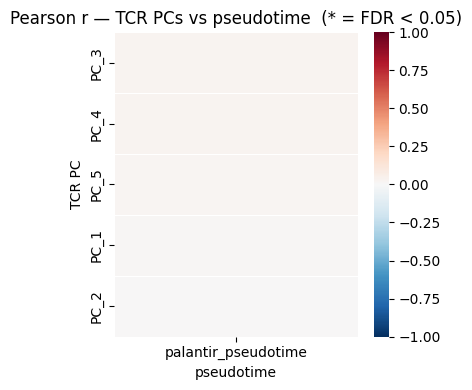

In [8]:
# Heatmap: r values (PC × pseudotime), only PCs with at least one significant hit
sig_pcs = df_corr[df_corr['sig']]['PC'].unique()
if len(sig_pcs) == 0:
    # fall back to top-20 by |r|
    sig_pcs = (df_corr.groupby('PC')['abs_r'].max()
               .sort_values(ascending=False).head(20).index.tolist())
    print("No FDR-significant pairs — showing top 20 PCs by max |r|")

heat = (df_corr[df_corr['PC'].isin(sig_pcs)]
        .pivot(index='PC', columns='pseudotime', values='r')
        .reindex(sig_pcs))

# Significance mask (FDR < 0.05)
annot_df = (df_corr[df_corr['PC'].isin(sig_pcs)]
            .pivot(index='PC', columns='pseudotime', values='pval_fdr')
            .reindex(sig_pcs)
            .applymap(lambda p: '*' if p < 0.05 else ''))

fig, ax = plt.subplots(figsize=(max(4, len(pseudo_cols) * 1.5),
                                max(4, len(sig_pcs) * 0.35 + 1)))
sns.heatmap(heat, annot=annot_df, fmt='', center=0,
            cmap='RdBu_r', linewidths=0.4, vmin=-1, vmax=1, ax=ax)
ax.set_title('Pearson r — TCR PCs vs pseudotime  (* = FDR < 0.05)')
ax.set_ylabel('TCR PC')
plt.tight_layout(); plt.show()

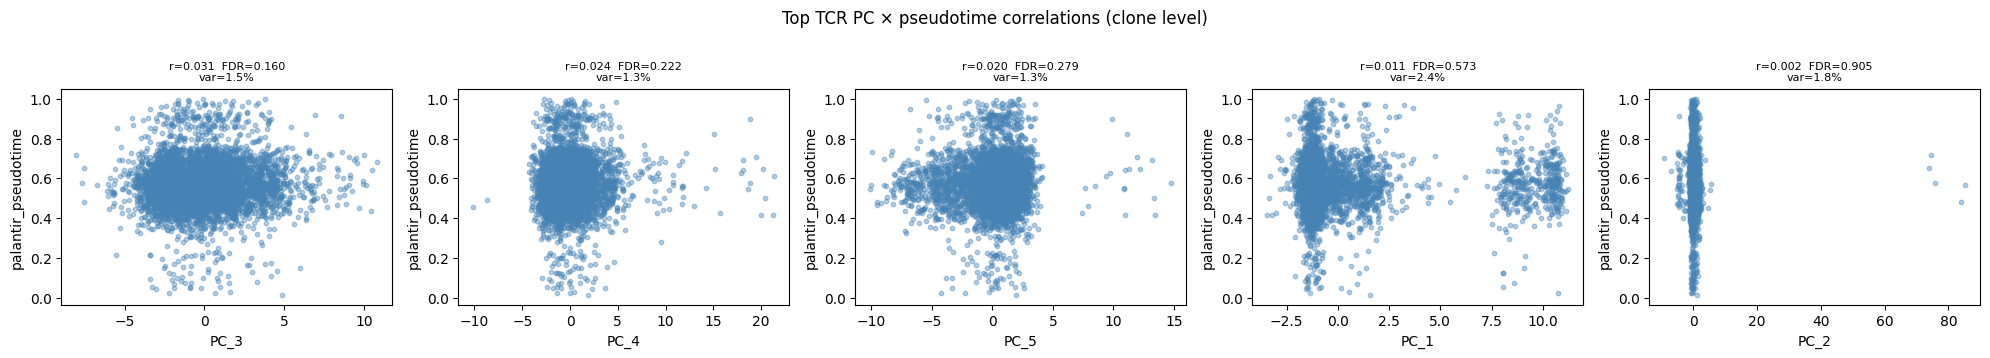

In [9]:
# Scatter plots for the top-N pairs by |r|
top_pairs = df_corr.sort_values('abs_r', ascending=False).head(min(10, len(df_corr)))
ncols = min(5, len(top_pairs))
nrows = int(np.ceil(len(top_pairs) / ncols))

fig, axes = plt.subplots(nrows, ncols,
                          figsize=(4 * ncols, 3.5 * nrows),
                          squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for ax, (_, row) in zip(axes.flat, top_pairs.iterrows()):
    ax.set_visible(True)
    pi = pc_names.index(row['PC'])
    ax.scatter(tcr_pcs[:, pi], clone_ps[row['pseudotime']].values,
               alpha=0.4, s=10, color='steelblue')
    ax.set_xlabel(row['PC'])
    ax.set_ylabel(row['pseudotime'])
    sig_label = '*' if row['sig'] else ''
    ax.set_title(f"r={row['r']:.3f}{sig_label}  FDR={row['pval_fdr']:.3f}\n"
                 f"var={row['var_exp_pct']:.1f}%", fontsize=8)

plt.suptitle('Top TCR PC × pseudotime correlations (clone level)', y=1.01)
plt.tight_layout(); plt.show()

## 6. TCR feature importance via PCA loadings

In [10]:
# For each significant PC, report the top TCR features by absolute loading.
# pca.components_ : (n_pca, n_tcr_features)
top_n = 20

# Focus on PCs that have at least one significant pseudotime correlation
sig_pcs_list = df_corr[df_corr['sig']]['PC'].unique().tolist()
if not sig_pcs_list:
    # fall back to top-5 by max |r|
    sig_pcs_list = (df_corr.groupby('PC')['abs_r'].max()
                    .sort_values(ascending=False).head(5).index.tolist())

records_load = []
for pc in sig_pcs_list:
    pi     = pc_names.index(pc)
    load   = pca.components_[pi]          # (n_tcr_features,)
    top_idx = np.argsort(np.abs(load))[::-1][:top_n]
    for rank, idx in enumerate(top_idx):
        records_load.append(dict(
            PC=pc, rank=rank + 1,
            feature=tcr_feat_names[idx],
            loading=load[idx],
            abs_loading=np.abs(load[idx]),
            var_exp_pct=var_exp[pi] * 100
        ))

df_loadings = pd.DataFrame(records_load)
print(f"Top {top_n} TCR features per significant PC:")
print(df_loadings.groupby('PC').head(5).to_string(index=False))

Top 20 TCR features per significant PC:
  PC  rank                      feature   loading  abs_loading  var_exp_pct
PC_3     1          VJ_1_cdr3_aa_length  0.328124     0.328124     1.481215
PC_3     2    X_VJ_1_cdr3_aa_atchley_40 -0.216665     0.216665     1.481215
PC_3     3    X_VJ_1_cdr3_aa_atchley_46  0.215957     0.215957     1.481215
PC_3     4    X_VJ_1_cdr3_aa_atchley_43  0.212975     0.212975     1.481215
PC_3     5    X_VJ_1_cdr3_aa_atchley_41  0.187313     0.187313     1.481215
PC_4     1         VDJ_1_cdr3_aa_length  0.281073     0.281073     1.325419
PC_4     2   X_VDJ_1_cdr3_aa_atchley_80  0.194955     0.194955     1.325419
PC_4     3   X_VDJ_1_cdr3_aa_atchley_92  0.190651     0.190651     1.325419
PC_4     4   X_VDJ_1_cdr3_aa_atchley_56  0.189163     0.189163     1.325419
PC_4     5   X_VDJ_1_cdr3_aa_atchley_61  0.180384     0.180384     1.325419
PC_5     1     X_VJ_1_cdr3_aa_atchley_3  0.327775     0.327775     1.281249
PC_5     2     X_VJ_1_cdr3_aa_atchley_0  0.32365

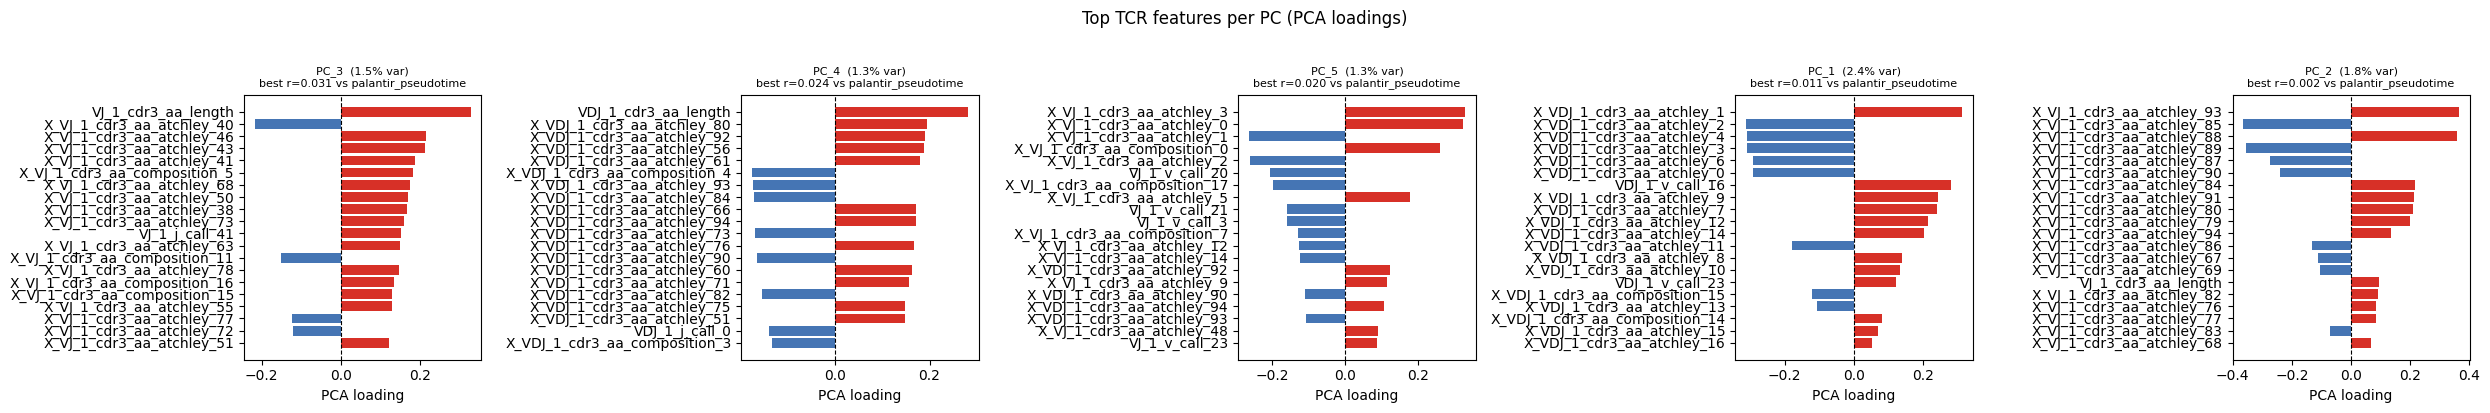

In [11]:
# Bar plots: top TCR loadings for each significant PC
n_plot = len(sig_pcs_list)
fig, axes = plt.subplots(1, n_plot, figsize=(5 * n_plot, 4), squeeze=False)

for ax, pc in zip(axes[0], sig_pcs_list):
    sub = df_loadings[df_loadings['PC'] == pc].nlargest(top_n, 'abs_loading')
    colors = ['#d73027' if v > 0 else '#4575b4' for v in sub['loading']]
    ax.barh(sub['feature'], sub['loading'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    # Annotate with the best pseudotime correlation for this PC
    best = (df_corr[df_corr['PC'] == pc]
            .sort_values('abs_r', ascending=False).iloc[0])
    ax.set_title(f"{pc}  ({var_exp[pc_names.index(pc)]*100:.1f}% var)\n"
                 f"best r={best['r']:.3f} vs {best['pseudotime']}", fontsize=8)
    ax.set_xlabel('PCA loading')
    ax.invert_yaxis()

plt.suptitle('Top TCR features per PC (PCA loadings)', y=1.02)
plt.tight_layout(); plt.show()

## UMAP - clone

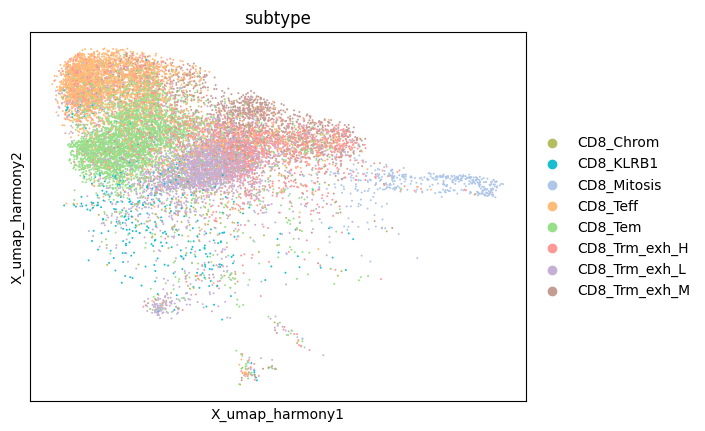

In [27]:
import scanpy as sc
sc.pl.embedding(mdata['gex'], basis="X_umap_harmony", color=['subtype'])

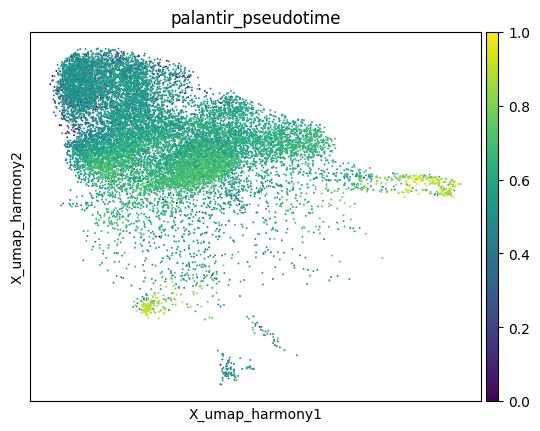

In [28]:
sc.pl.embedding(mdata['gex'], basis="X_umap_harmony", color=['palantir_pseudotime'])

In [22]:
mdata

MuData object with n_obs × n_vars = 14957 × 2551
  obs:	'isT', 'ident', 'patient', 'source', 'type', 'subtype', 'clone_loc', 'unique_clone_id', 'cloned', 'in_two_tissue', 'clone_status', 'VJ_1_cdr3_aa', 'VJ_1_v_call', 'VJ_1_j_call', 'VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call', 'VDJ_1_cdr3_aa_length', 'VJ_1_cdr3_aa_length'
  uns:	'hvg_union_COMBAT_ID_meta', 'tcr_embs_feature_names'
  obsm:	'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_j_call', 'VJ_1_v_call', 'X_VDJ_1_cdr3_aa_atchley', 'X_VDJ_1_cdr3_aa_composition', 'X_VJ_1_cdr3_aa_atchley', 'X_VJ_1_cdr3_aa_composition', 'tcr_embs'
  2 modalities
    gex:	14957 x 2551
      obs:	'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'patient', 'source', 'type', 'subtype', 'clone_status', 'palantir_pseudotime'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'hvg_union_COMBAT_ID', 'mean', 'std'
      uns:	'X_umap_harmony', 'hvg_union_COMBAT_ID_k200', 'hvg_union_COMBAT_ID_meta', 'log1p', 'neighbors', 'neighbors_harmony', 'patient_colors', 'pca', 'source_colors', 'subtype_colors', 'type_colors', 'umap'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_harmony'
      varm:	'PCs'
      obsp:	'connectivities', 'distances', 'neighbors_harmony_connectivities', 'neighbors_harmony_distances'
    airr:	14957 x 0
      obs:	'sample', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'cc_aa_tcrdist', 'cc_aa_tcrdist_size', 'clonal_expansion'
      uns:	'cc_aa_tcrdist', 'chain_indices', 'clone_id', 'ir_dist_aa_identity', 'ir_dist_aa_tcrdist', 'ir_dist_nt_identity'
      obsm:	'airr', 'chain_indices'

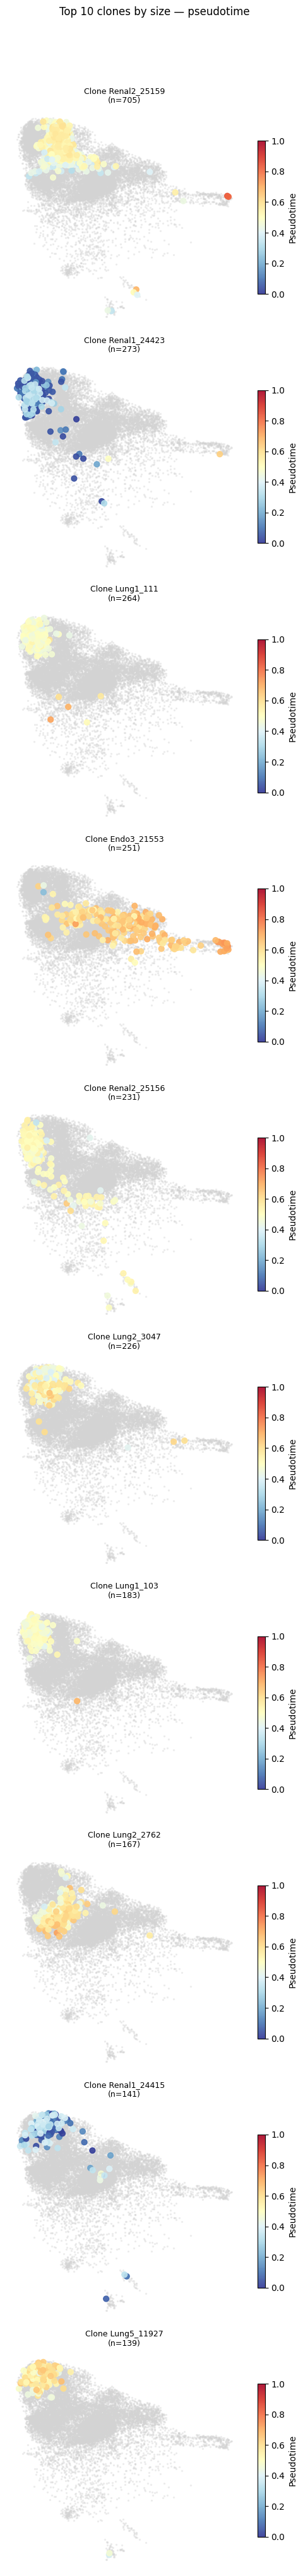

In [29]:
import numpy as np
import matplotlib.pyplot as plt

k = 10  # adjust as needed

top_k_clones = (
    mdata.obs['unique_clone_id']
    .value_counts()
    .head(k)
    .index.tolist()
)

umap       = mdata['gex'].obsm['X_umap_harmony']
pseudotime = mdata['gex'].obs['palantir_pseudotime'].values

# ── Plot ──────────────────────────────────────────────────────────────────────
ncols = 1
nrows = int(np.ceil(k / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, clone_id in enumerate(top_k_clones):
    ax = axes[i]
    clone_mask = mdata.obs['unique_clone_id'] == clone_id
    clone_size = clone_mask.sum()

    # Background
    ax.scatter(umap[:, 0], umap[:, 1],
               c='lightgrey', s=2, alpha=0.3, zorder=1)

    # Clone cells colored by pseudotime
    sc = ax.scatter(umap[clone_mask, 0], umap[clone_mask, 1],
                    c=pseudotime[clone_mask], cmap='RdYlBu_r',
                    s=40, zorder=2, alpha=0.9,
                    vmin=0, vmax=1)

    plt.colorbar(sc, ax=ax, label='Pseudotime', shrink=0.7)
    ax.set_title(f'Clone {clone_id}\n(n={clone_size})', fontsize=9)
    ax.axis('off')

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Top {k} clones by size — pseudotime', y=1.02)
plt.tight_layout()
plt.show()

## 7. Store PC scores back on cells

In [12]:
# Store all PC scores at clone level, then map to cells
clone_pc_df = pd.DataFrame(tcr_pcs, index=clone_tcr.index, columns=pc_names)

cell_clone = mdata['gex'].obs['clone_id'].astype(str)
for pc in pc_names:
    mdata['gex'].obs[f'TCR_{pc}'] = cell_clone.map(clone_pc_df[pc]).values

# Also attach pseudotime from adata (already done in section 2)
stored = [f'TCR_{pc}' for pc in pc_names]
print(f"Stored {len(stored)} TCR PC scores in mdata['gex'].obs")
print("Significant PCs:", sig_pcs_list)

KeyError: 'clone_id'

In [ ]:
# UMAP: colour by significant TCR PCs and pseudotime columns
umap_basis  = 'X_umap_harmony' if 'X_umap_harmony' in mdata['gex'].obsm else 'X_umap'
neigh_key   = 'neighbors_harmony' if 'neighbors_harmony' in mdata['gex'].uns else None
plot_cols   = ([f'TCR_{pc}' for pc in sig_pcs_list[:5]] + pseudo_cols[:3])
plot_cols   = [c for c in plot_cols if c in mdata['gex'].obs.columns]

sc.pl.embedding(mdata['gex'], basis=umap_basis,
                color=plot_cols, ncols=min(5, len(plot_cols)),
                neighbors_key=neigh_key)